In [45]:
class CCD:
    def __init__(self,tpix_horizontal,tpix_vertical,tau_weights, tau_values):
        # self.original_image = np.copy(image_array)
        # self.exposure_images = np.zeros_like(sample_image,dtype=float)
        # self.exposure_images = []
        self.tpix_horizontal = tpix_horizontal
        self.tpix_vertical = tpix_vertical

        self.reconstructed_images = []
        self.no_trap_images = []
        self.exposures = []

        self.single_e_counts = []
        self.single_e_counts_no_traps = []
        self.single_e_counts_masked = []
        self.single_e_counts_masked_no_traps = []
        
        self.unmasked_pixels = []
        self.unmasked_pixels_no_traps = []


        self.UL_expdep = 8.19e-5 #e / pix / day

        self.UR_expdep = 4.36e-5 #e / pix / day

        self.LL_expdep = 6.88e-5 #e / pix / day

        self.LR_expdep = 8.23e-5 #e / pix / day

        self.UL_expindep = 12.23e-5 #e / superpix / image

        self.UR_expindep = 9.94e-5 #e / superpix / image

        self.LL_expindep = 7.53e-5 #e / superpix / image

        self.LR_expindep = 6.52e-5 #e / superpix / day
        self.exp_dep_rate = self.UR_expdep / (24 * 3600) #e / pix / s
        self.exp_indep_rate = self.UR_expindep/ 32 #e / pix / image

        self.total_pix = (6144)* (1024)

        self.npix_per_quad = self.total_pix / 4


        self.nrow_quad = int(1024 /2)
        self.ncol_quad = int(6144 / 2)
        shape = (self.nrow_quad,self.ncol_quad)
        self.exposure_accumulator = np.zeros(shape)

        self.ccd_state = np.zeros(shape)
        



        self.exp_indep_events = np.round(self.exp_indep_rate * self.npix_per_quad)


        # #generate trap locations
        # trap_density = (5171 / 4) / (self.nrow_quad * self.ncol_quad)
        # rng = np.random.default_rng()
        # self.trap_mask = rng.random(shape) < trap_density
        # num_traps = np.sum(self.trap_mask)


        # probs = np.array(tau_weights) / np.sum(tau_weights)
        # sampled_taus = rng.choice(tau_values, size=num_traps, p=probs)
        
        # # 3. Create Tau Map (Infinite tau for non-traps to prevent math errors)
        # self.tau_map = np.ones(shape, dtype=float) * np.inf
        # self.tau_map[self.trap_mask] = sampled_taus
        
        # # 4. Trapped Charge State (0.0 = Empty, 1.0 = Full)
        # self.trapped_charge = np.zeros(shape, dtype=float)


        # --- OPTIMIZATION 1: SPARSE TRAP STORAGE ---
        # Instead of a full boolean mask, store the coordinates of traps
        # trap_density calculation remains the same...
        trap_density = (5171 / 4) / (self.nrow_quad * self.ncol_quad)
        rng = np.random.default_rng()
        self.trap_mask = rng.random(shape) < trap_density
        
        # Store indices (tuple of row_indices, col_indices) for fast access
        self.trap_indices = np.where(self.trap_mask)
        num_traps = len(self.trap_indices[0])
        
        # Store Tau values as a 1D array corresponding to the indices
        probs = np.array(tau_weights) / np.sum(tau_weights)
        self.trap_taus = rng.choice(tau_values, size=num_traps, p=probs)
        
        # Store trapped charge as a 1D array (much faster than 2D)
        self.trapped_charge_1d = np.zeros(num_traps, dtype=float)





    # def charge_trap_interaction(self,current_image,dt):
    #     capture_efficiency = 1

    #     #capture process 
    #     # available_space = 1.0 - self.trapped_charge
    #     # potential_capture = current_image * capture_efficiency * self.trap_mask
    #     # actual_capture = np.minimum(potential_capture, available_space)
    #     # current_image -= actual_capture
    #     # self.trapped_charge += actual_capture
    #     candidates = (current_image >= 1) & (self.trap_mask) & (self.trapped_charge == 0)
    #     # We can treat this as a Binomial process: 
    #     # If capture_efficiency is 1.0, it simply takes the electron.
    #     # Note: This is simplified for 1e regime.
    #     captured_mask = candidates # In a more complex model, use np.random.binomial
    #     current_image[captured_mask] -= 1.0
    #     self.trapped_charge[captured_mask] += 1.0


    #     #now simulate decay
    #     # decay_factors = 1 - np.exp(-dt / self.tau_map)
    #     # released_charge = self.trapped_charge * decay_factors
    #     # self.trapped_charge -= released_charge
    #     # current_image += released_charge
    #     p_release = 1 - np.exp(-dt / self.tau_map)
    #     occupied_traps = self.trapped_charge > 0
    #     random_rolls = np.random.random(current_image.shape)
    #     release_mask = occupied_traps & (random_rolls < p_release)
    #     self.trapped_charge[release_mask] -= 1.0
    #     current_image[release_mask] += 1.0


    #     return current_image

    def charge_trap_interaction(self, current_image, dt):
        # --- OPTIMIZATION 2: SPARSE INTERACTION ---
        
        # 1. Extract charge ONLY at trap locations
        # We use the pre-calculated indices to grab values directly
        charge_at_traps = current_image[self.trap_indices]
        
        # 2. Capture Logic (Vectorized on 1D arrays)
        # Check: Pixel has charge (>=1) AND Trap is empty (==0)
        can_capture = (charge_at_traps >= 1.0) & (self.trapped_charge_1d == 0.0)
        
        # Get indices of traps that are actually capturing right now
        # We filter our master index list by the boolean 'can_capture'
        capturing_rows = self.trap_indices[0][can_capture]
        capturing_cols = self.trap_indices[1][can_capture]
        
        # Update the image and the trap state
        current_image[capturing_rows, capturing_cols] -= 1.0
        self.trapped_charge_1d[can_capture] += 1.0

        # 3. Release Logic
        # Calculate probability P = 1 - exp(-dt/tau)
        # We use the scalar dt directly (no need for an array of dt)
        p_release = 1.0 - np.exp(-dt / self.trap_taus)
        
        # Generate random rolls only for the traps (N=1300), not the image (N=1.5M)
        n_traps = len(self.trap_taus)
        random_rolls = np.random.random(n_traps)
        
        # Check: Trap has charge (>0) AND Roll is successful
        should_release = (self.trapped_charge_1d > 0) & (random_rolls < p_release)
        
        # Get indices of traps that are releasing
        releasing_rows = self.trap_indices[0][should_release]
        releasing_cols = self.trap_indices[1][should_release]
        
        # Update image and trap state
        current_image[releasing_rows, releasing_cols] += 1.0
        self.trapped_charge_1d[should_release] -= 1.0

        return current_image




    def take_fake_image(self,exposure_time_hours,radius=60):
        #account for traps released during previous exposure
        


        exp = exposure_time_hours * 3600
        self.exposures.append(exp)

        
        exp_dep_events = self.exp_dep_rate * exp * self.npix_per_quad #assume not much during readout -- maybe not a great assumption but whatever

        # print(self.npix_per_quad)
        exp_dep_events = np.round(exp_dep_events)
        # print(exp,exp_dep_events,self.exp_indep_events)




        n_singlee_events = int(exp_dep_events + self.exp_indep_events)


        print(f'Number of single electron events from rate to inject: {n_singlee_events}')
        #now generate fake image
        file = 'minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits'

        q0 = get_qdata(file,0)

        q0 =approximate_electronize(q0,400)
        q0_blank= transplant_clusters(q0.T, target_shape=(self.nrow_quad, self.ncol_quad),count_threshold=100, max_aspect_ratio=3.0,radius=radius,exposure=exp)


        q0_fake = inject_single_e(q0_blank, n_events=n_singlee_events, intensity=1)
        self.no_trap_images.append(q0_fake)

        self.ccd_state += q0_fake
        if len(self.exposures) > 0:
            t1 = self.exposure_accumulator - self.exposures[-1]
            t2 = self.exposure_accumulator 
            # dt = t2 - t1
            self.ccd_state = self.charge_trap_interaction(self.ccd_state,self.tpix_vertical)
        # exp_image = np.zeros_like(q0_fake,dtype=float)

        self.simulate_readout()

        #counts
        
        og_image_halo = generate_halo_mask(self.no_trap_images[-1],threshold=100,radius=60)
        trap_image_halo = generate_halo_mask(self.reconstructed_images[-1],threshold=100,radius=60)


        counts_1e_trap_nomask  = get_cluster(self.reconstructed_images[-1],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)

        counts_1e_og_nomask  = get_cluster(self.no_trap_images[-1],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)


        masked_trap_image = np.copy(self.reconstructed_images[-1]).astype(float)

        masked_og_image = np.copy(self.no_trap_images[-1]).astype(float)


        masked_og_image[og_image_halo] = np.nan
        masked_trap_image[trap_image_halo] = np.nan

        counts_1e_trap  = get_cluster(masked_trap_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)
        counts_1e_og  = get_cluster(masked_og_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)

        unmasked_pix_traps = np.sum(~trap_image_halo)

        unmasked_pix_notraps = np.sum(~og_image_halo)


        self.single_e_counts.append(counts_1e_trap_nomask)
        self.single_e_counts_masked.append(counts_1e_trap)
        self.single_e_counts_no_traps.append(counts_1e_og_nomask)


        self.single_e_counts_masked_no_traps.append(counts_1e_og)

        self.unmasked_pixels.append(unmasked_pix_traps)
        self.unmasked_pixels_no_traps.append(unmasked_pix_notraps)

        #simulate a clear
        self.ccd_state *= 0

        # self.exposure_images.append(exp_image)

        


        self.exposure_accumulator += exp





    def simulate_readout(self):

        
        print(f"Starting Readout...")
        # image = self.ccd_state
        image = self.ccd_state.copy()
        serial_register = np.zeros(image.shape[1])


        rows, cols = image.shape
        
        output_stream = []

        for r in range(rows):
            serial_register = image[-1, :].copy() #this represents a vertical shift of charge to the serial register

            image[1:, :] = image[:-1, :]
            image[0, :] = 0.0
            # line_buffer = []
            index = int(-1 -r )
            t2 = self.exposure_accumulator+ self.tpix_vertical 
            t1 = self.exposure_accumulator
            dt = t2 - t1

            # image = self.charge_trap_interaction(image,dt)
            image = self.charge_trap_interaction(image,self.tpix_vertical)
            self.exposure_accumulator[:index,:] += self.tpix_vertical


            #would need this for serial register traps
            # for c in range(cols):
            #     # index2 = int(-1 -c)
            #     val = serial_register[-1]
            #     serial_register[1:] = serial_register[:-1]
            #     serial_register[0] = 0.0
            #     # self.exposure_image[:index,:index2] += self.tpix_horizontal #don't necessarily need to keep track of this, assuming no traps in serial register
            #     line_buffer.append(val)

            # output_stream.extend(line_buffer)
            output_stream.extend(serial_register[::-1])

        result_flat = np.array(output_stream)
        result_reconstructed= result_flat.reshape(rows, cols)
        result_reconstructed = np.flipud(np.fliplr(result_reconstructed))

        self.reconstructed_images.append(result_reconstructed)

        return 





# def simulate_readout(image,readout_time_hours = 7,tpix_horizontal,tpix_vertical):
#     total_seconds = readout_time_hours *3600
#     npix = image.shape[0] * image.shape[1]
#     rows,cols = image.shape
#     for r in range(rows):
#         serial_register = image[-1, :].copy()
#         image_area[0, :] = 0.0

# CCDTest.simulate_readout()




In [46]:
import hist
from hist import Hist
import numpy as np

lower_exp0 = 1e-6
upper_exp0 = 1e-5

lower_exp4 = 1e-6
upper_exp4 = 0.2e-4



lower_exp6 = 1e-6
upper_exp6 = 0.3e-4


lower_exp10 = 9e-6
upper_exp10 = 0.4e-4


lower_exp20 = 5e-6
upper_exp20 = 0.8e-4



# lower = np.min(densities_exp)
histograms = {
    0: Hist(hist.axis.Regular(50, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(50, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(50, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(50, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(50, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

histograms_no_traps = {
    0: Hist(hist.axis.Regular(50, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(50, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(50, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(50, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(50, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

In [49]:
import pickle
mean_traps = {

}
mean_notraps = {
}

mean_traps_err = {

}
mean_notraps_err = {

}
for i in range(5):
    with open(f'ccd_traps_run{i}.pkl','rb') as f:
        ccd_run = pickle.load(f)

        densities = np.array(ccd_run.single_e_counts_masked) / np.array(ccd_run.unmasked_pixels)
        densities_notraps = np.array(ccd_run.single_e_counts_masked_no_traps) / np.array(ccd_run.unmasked_pixels_no_traps)

        unique_exposures = np.unique( np.sort(np.array(ccd_run.exposures)))
        for e in range(len(unique_exposures)):
            exp = unique_exposures[e]
            expkey = int(exp / 3600)
            exp_indices = np.array(ccd_run.exposures) == exp

            densities_exp = densities[exp_indices]



            mean_traps[expkey] = np.sum(np.array(ccd_run.single_e_counts_masked)[exp_indices]) / np.sum(np.array(ccd_run.unmasked_pixels)[exp_indices])
            mean_traps_err[expkey] = np.sqrt(np.sum(np.array(ccd_run.single_e_counts_masked)[exp_indices])) / np.sum(np.array(ccd_run.unmasked_pixels)[exp_indices])

            densities_exp_notraps = densities_notraps[exp_indices]
            mean_notraps[expkey] = np.sum(np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]) / np.sum(np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices])
            mean_notraps_err[expkey] = np.sqrt(np.sum(np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]))/ np.sum(np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices])

            histograms[expkey].fill(densities_exp)
            histograms_no_traps[expkey].fill(densities_exp_notraps)
        del ccd_run







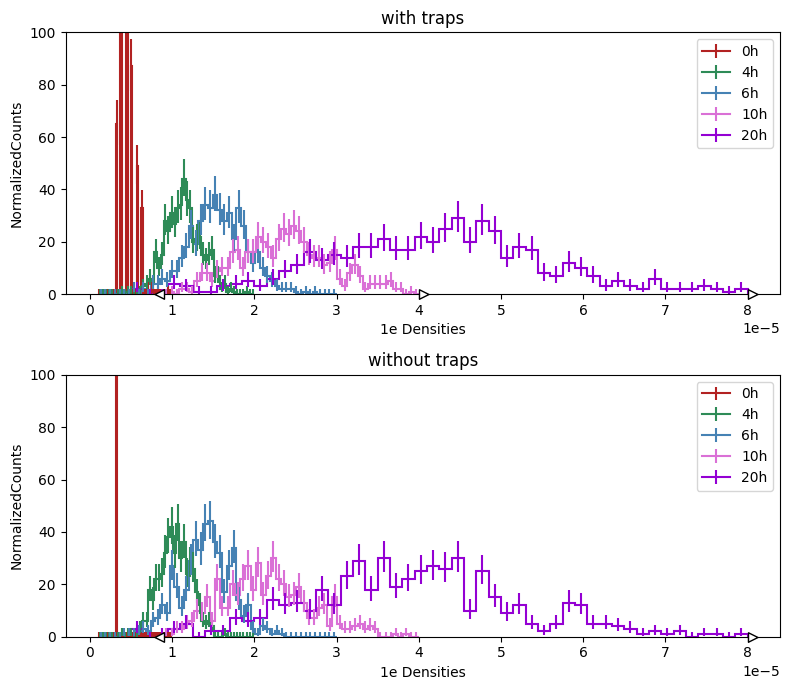

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:
import matplotlib.pyplot as plt
colorlist = ['firebrick','seagreen','steelblue','orchid','darkviolet']
fig, ax = plt.subplots(2,figsize=(8,7))
for i in range(2):
    if i == 0:
        hists = histograms
        t = 'with'
    elif i == 1:
        hists = histograms_no_traps
        t = 'without'
    for j,h in enumerate([0,4,6,10,20]):
        color = colorlist[j]
        plothist = hists[h] #/ np.sum(hists[h].values())

        plothist.plot1d(ax=ax[i],color=color,label=f'{h}h')
    # hists[4].plot1d(ax=ax[i],color='seagreen',label='4h')
    # hists[6].plot1d(ax=ax[i],color='steelblue',label='6h')
    # hists[10].plot1d(ax=ax[i],color='orchid',label='10h')
    # hists[20].plot1d(ax=ax[i],color='darkviolet',label='20h')

    ax[i].set_ylim(0,100)
    ax[i].set_title(f"{t} traps")
    ax[i].set_ylabel("NormalizedCounts")
    ax[i].set_xlabel("1e Densities")
    ax[i].legend()
plt.tight_layout()
plt.show()
plt.close()

plt.figure()

# histograms[20]

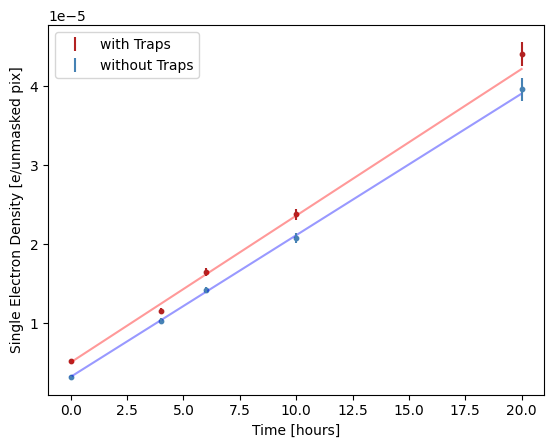

With Traps
exposure independent: 5.003142095394044e-06
exposure dependent: 1.8588283547838674e-06
Without Traps
exposure independent: 3.1736946068034937e-06
exposure dependent: 1.7941735750619453e-06
True Parameters
exposure independent: 3.10625e-06
exposure dependent: 4.36e-05


In [65]:
unique_exposures_h = unique_exposures / 3600
unique_exposures_h = unique_exposures_h.astype(int)

average_densities = np.array([mean_traps[h] for h in unique_exposures_h])   #np.array([np.mean(mean_traps[h]) for h in unique_exposures_h])
average_densities_notraps =  np.array([mean_notraps[h] for h in unique_exposures_h])     #np.array([np.mean(mean_notraps[h]) for h in unique_exposures_h])

average_density_err = np.array([mean_traps_err[h] for h in unique_exposures_h])   #np.array([np.mean(mean_traps[h]) for h in unique_exposures_h])
average_density_err_notraps =  np.array([mean_notraps_err[h] for h in unique_exposures_h])     #np.array([np.mean(mean_notraps[h]) for h in unique_exposures_h])



from scipy.optimize import curve_fit


def line(x,m,b):
    y = m*x + b
    return y


# days = unique_exposures_h.reshape((-1, 1))
popt, pcov = curve_fit(line, unique_exposures_h, average_densities, sigma=average_density_err, absolute_sigma=True)
exp_dep, exp_indep = popt



popt, pcov = curve_fit(line, unique_exposures_h, average_densities_notraps, sigma=average_density_err_notraps, absolute_sigma=True)

# model_notraps = LinearRegression().fit(days, average_densities_notraps)

# exp_indep_notraps = model_notraps.intercept_
# exp_dep_notraps = model_notraps.coef_[0]

exp_dep_notraps, exp_indep_notraps = popt


hours = np.linspace(0,20,20)




fit_no_traps = line(hours,exp_dep_notraps,exp_indep_notraps)
fit_traps = line(hours,exp_dep,exp_indep)


plt.figure()
plt.scatter(unique_exposures_h,average_densities,color='firebrick',s=10)
plt.scatter(unique_exposures_h,average_densities_notraps,color='steelblue',s=10)

plt.plot(hours,fit_traps,color='red',alpha=0.4)
plt.plot(hours,fit_no_traps,color='blue',alpha=0.4)

plt.errorbar(unique_exposures_h,average_densities,yerr=average_density_err,label='with Traps',color='firebrick',ls='None')
plt.errorbar(unique_exposures_h,average_densities_notraps,yerr=average_density_err_notraps,label='without Traps',color='steelblue',ls='None')
plt.ylabel("Single Electron Density [e/unmasked pix]")
plt.xlabel("Time [hours]")
plt.legend()
plt.show()
plt.close()

print("With Traps")
print(f'exposure independent: {exp_indep}')
print(f'exposure dependent: {exp_dep}')


print("Without Traps")
print(f'exposure independent: {exp_indep_notraps}')
print(f'exposure dependent: {exp_dep_notraps}')

print("True Parameters")
print(f'exposure independent: {3.10625e-06}')
print(f'exposure dependent: {4.36e-05}')




8

In [4]:

from utils import *
from astropy.time import Time
#use a snolab image and assume this time is valid for pixel times

def pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG):		# Time to read 1 pixel
  return 5*int(delayH)+int(delayRG)+(int(delayIped)+int(delaySW)+int(delayIsig)+int(delayOG)+int(delayRG))*int(nsamp)

def pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG):		# Time to read 1 pixel
  pixel_time_hor=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG)
  return (pixel_time_hor+(int(delaySW)+int(delayDG)))*int(ncol)


snolab_dir = '/data/analyses/snolab_run1/'
file = 'proc_corr_proc_skp_sensei_2023-02-14_135K_run7_commissioning_NROW520_NBINROW1_NCOL3200_NBINCOL1_EXPOSURE72000_CLEAR10800_5_83.fits'
with fits.open(snolab_dir +file) as hdul:
    q = hdul[0]
    header = q.header
    print(list(header.keys()))
    nrow=header['NROW']
    ncol=header['NCOL']
    exposure=header['EXPOSURE']
    nsamp=header['NSAMP']
    delayH=header['HIERARCH DELAY_H_OVERLAP']
    delayRG=header['HIERARCH DELAY_RG_WIDTH']
    delayIped=header['HIERARCH DELAY_INTEG_PED']
    delaySW=header['HIERARCH DELAY_SWHIGH']
    delayIsig=header['HIERARCH DELAY_INTEG_SIG']
    delayOG=header['HIERARCH DELAY_OG_LOW']
    delayDG=header['HIERARCH DELAY_DG_LOW']


    
#     print(list(q.header.keys()))
#     print(q.header['DATESTART'])
#     print(q.header['EXPOSURE'])

#     dte_start = q.header['DATESTART']
#     dte_end = q.header['DATEEND']
#     t = Time([dte_start,dte_end], format='isot')
#     readout_time = t.jd[1] - t.jd[0]
#     print(readout_time * 24 * 3600)
#     readout_time =readout_time * 24 * 3600
# # singleReadTime = smask.readout_time - exp
# # seconds_per_row = (singleReadTime)/nRow
# # seconds_per_pixel = seconds_per_row/nCol

# singleReadTime = readout_time - 72000

# seconds_per_row = (singleReadTime)/nRow
# seconds_per_pixel = seconds_per_row/nCol
tpix=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG) / 15e6
tpix_vertical=pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG)/15e6

(tpix_vertical * 520)/ 3600

['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'EXTEND', 'COMMENT', 'COMMENT', 'CCDNCOL', 'CCDNPRES', 'CCDNROW', 'EXPOSURE', 'NBINCOL', 'NBINROW', 'NCOL', 'NROW', 'NSAMP', 'SKIPCOL', 'SKIPROW', 'TOG_VDD', 'TOG_VR', 'DELAY_H_OVERLAP', 'DELAY_INTEG_PED', 'DELAY_INTEG_SIG', 'DELAY_RG_WIDTH', 'DELAY_SWHIGH', 'DELAY_V_OVERLAP', 'DELAY_DG_LOW', 'DELAY_EXPOSE', 'DELAY_OG_LOW', 'V1AH', 'V1AL', 'V1BH', 'V1BL', 'V2CH', 'V2CL', 'V3AH', 'V3AL', 'V3BH', 'V3BL', 'H1AH', 'H1AL', 'H1BH', 'H1BL', 'H2CH', 'H2CL', 'H3AH', 'H3AL', 'H3BH', 'H3BL', 'SWAH', 'SWAL', 'SWBH', 'SWBL', 'RGAH', 'RGAL', 'RGBH', 'RGBL', 'OGAH', 'OGAL', 'OGBH', 'OGBL', 'DGAH', 'DGAL', 'DGBH', 'DGBL', 'TGAH', 'TGAL', 'TGBH', 'TGBL', 'LDAC_N', 'CLR_N', 'RESET_N', 'SW_EN', 'VDRAIN', 'VDD', 'VR', 'VSUB', 'VDD_SW', 'VDRAIN_SW', 'VSUB_SW', 'VSUB_LOAD_SW', 'VSUB_RDIV_SW', 'VR_SW', 'P15V_SW', 'M15V_SW', 'PACKSOURCE', 'PACKSTART', 'TESTPTRNA', 'TESTPTRNB', 'TESTPTRNC', 'TESTPTRND', 'CALSTART', 'CALADONE', 'CALBDONE', 'CALCDONE', 'CALDDONE'

7.091783111111111